<a href="https://www.kaggle.com/code/vaibsdev/notebook5d95578c5e?scriptVersionId=305199921" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt
import json
import pickle
import warnings
import pandas as pd
!pip install torchinfo
from torchinfo import summary
import gc

warnings.filterwarnings('ignore')

In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Device Count: {torch.cuda.device_count()}")
    print(f"CUDA Device Name: {torch.cuda.get_device_name(0)}")


def move_to_device(obj, device):
    if isinstance(obj, torch.nn.Module):
        return obj.to(device)
    elif isinstance(obj, torch.Tensor):
        return obj.to(device)
    return obj


sample_tensor = torch.tensor([1.0]).to(device)
print(f"Tensor on {sample_tensor.device}")


Using device: cuda
CUDA Available: True
CUDA Device Count: 1
CUDA Device Name: Tesla P100-PCIE-16GB
Tensor on cuda:0


In [3]:

class EarlyStopping:
    """Early stopping handler to prevent overfitting"""
    def __init__(self, patience=5, min_delta=0.001, save_path="best_model.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            # Save the best model
            torch.save(model.state_dict(), self.save_path)
            print(f"[INFO] Model checkpoint saved to {self.save_path}")
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print("[INFO] Early stopping triggered.")
                return True
        return False

In [4]:

csv_path = '/kaggle/input/mst-e-data-1/mst-e_data/mst-e_image_details.csv'
image_data = pd.read_csv(csv_path)


image_paths = []
labels = []


base_image_dir = "/kaggle/input/mst-e-data-1/mst-e_data"


unique_mst_classes = sorted(image_data['MST'].unique())
class_to_idx = {class_name: idx for idx, class_name in enumerate(unique_mst_classes)}
num_classes = len(unique_mst_classes)
print(f"Number of unique MST classes: {num_classes}")
print(f"Class mapping: {class_to_idx}")


for index, row in image_data.iterrows():
    # Get image details from your columns
    image_id = row['image_ID']
    subject_name = row['subject_name']

 
    mst_class = row['MST']
    class_idx = class_to_idx[mst_class]

    image_path = os.path.join(base_image_dir, subject_name, f"{image_id}")

    # Skip if this is an MP4 file
    if image_path.lower().endswith('.mp4'):
        continue

    
    if os.path.exists(image_path):
        image_paths.append(image_path)
        labels.append(class_idx)  
    else:
        print(f"Image not found: {image_path}")

print(f"Found {len(image_paths)} images across {num_classes} MST classes")

Number of unique MST classes: 10
Class mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9}
Image not found: /kaggle/input/mst-e-data-1/mst-e_data/subject_18/PXL_20220922_183142438.jpg 
Image not found: /kaggle/input/mst-e-data-1/mst-e_data/subject_2/bottom
Found 1510 images across 10 MST classes


In [5]:
class SkinToneDataset(Dataset):
    """Custom Dataset for loading skin tone images"""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

RESNet


In [6]:
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(10),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
#     # transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

In [7]:
# train_paths, val_paths, train_labels, val_labels = train_test_split(
#     image_paths, labels, test_size=0.2, stratify=labels, random_state=42
# )
# train_dataset = SkinToneDataset(train_paths, train_labels, transform=transform)
# val_dataset = SkinToneDataset(val_paths, val_labels, transform=transform)


# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


In [8]:
# import torchvision.models as models

# class SkinToneResNet(nn.Module):
#     """ResNet-based model for skin tone classification."""
#     def __init__(self, num_classes):
#         super(SkinToneResNet, self).__init__()
        
#         # Load a pre-trained ResNet model
#         self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        
#         # Freeze feature extraction layers for transfer learning
#         for param in self.resnet.parameters():
#             param.requires_grad = False  

#         # Modify the fully connected layer for our task
#         in_features = self.resnet.fc.in_features
#         self.resnet.fc = nn.Sequential(
#             nn.Linear(in_features, 256),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         return self.resnet(x)

In [9]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = SkinToneResNet(num_classes=num_classes).to(device)

# criterion = nn.CrossEntropyLoss()  # Loss function
# optimizer = optim.Adam(model.resnet.fc.parameters(), lr=0.0005, weight_decay=1e-4)  # L2 regularization
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [10]:
# import torch
# from torch.cuda.amp import autocast, GradScaler

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# scaler = GradScaler()  # For mixed precision

# num_epochs = 20
# early_stopping = EarlyStopping(patience=5, min_delta=0.001, save_path="best_model.pth")

# train_losses, train_accuracies = [], []
# val_losses, val_accuracies = [], []

# for epoch in range(num_epochs):
#     model.train()
#     total_loss, correct, total = 0, 0, 0

#     for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
#         images = images.to(device, non_blocking=True)
#         labels = labels.to(device, non_blocking=True)

#         optimizer.zero_grad()

#         # 🔥 Mixed Precision Forward Pass
#         with autocast():
#             outputs = model(images)
#             loss = criterion(outputs, labels)

#         # 🔥 Scaled Backprop
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()

#         total_loss += loss.item()
#         _, predicted = torch.max(outputs, 1)

#         correct += (predicted == labels).sum().item()
#         total += labels.size(0)

#     train_acc = correct / total
#     train_loss = total_loss / len(train_loader)

#     train_losses.append(train_loss)
#     train_accuracies.append(train_acc)

#     scheduler.step()

#     print(f"[Epoch {epoch+1}] Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")

#     # ================= VALIDATION =================
#     model.eval()
#     val_loss, val_correct, val_total = 0, 0, 0

#     with torch.no_grad():
#         for images, labels in val_loader:
#             images = images.to(device, non_blocking=True)
#             labels = labels.to(device, non_blocking=True)

#             with autocast():
#                 outputs = model(images)
#                 loss = criterion(outputs, labels)

#             val_loss += loss.item()
#             _, predicted = torch.max(outputs, 1)

#             val_correct += (predicted == labels).sum().item()
#             val_total += labels.size(0)

#     val_acc = val_correct / val_total
#     val_loss /= len(val_loader)

#     val_losses.append(val_loss)
#     val_accuracies.append(val_acc)

#     print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

#     # 🔥 Early Stopping
#     if early_stopping(val_loss, model):
#         print("Early stopping triggered!")
#         break

In [11]:
# # Plot Losses
# epochs_range = range(1, len(train_losses) + 1)
# plt.subplot(1, 2, 1)
# plt.plot(epochs_range, train_losses, label='Train Loss')
# plt.plot(epochs_range, val_losses, label='Validation Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Loss over Epochs')
# plt.legend(loc='upper right')

# # Plot Accuracies
# plt.subplot(1, 2, 2)
# plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
# plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.title('Accuracy over Epochs')
# plt.legend(loc='lower right')

# plt.tight_layout()
# plt.show()

In [12]:
# # After training completes, to clear GPU memory:
# model = model.to('cpu')  # Move model back to CPU
# torch.cuda.empty_cache()  # Clear CUDA cache
# gc.collect()  # Trigger garbage collection

# # # If you're working in a notebook, you might want to manually delete variables
# # del model, train_loader, val_loader, images, labels, outputs, loss, optimizer, scheduler
# # gc.collect()  # Run garbage collection again
# # torch.cuda.empty_cache()  # Empty cache once more

-------------------------------------------------------------------------------

In [13]:
class SkinToneModel(nn.Module):
    """Convolutional Neural Network for skin tone classification"""
    def __init__(self, num_classes, dropout_rate=0.3):
        super(SkinToneModel, self).__init__()
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding="same"),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding="same"),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding="same"),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(p=0.2)
        )
        
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding="same"),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # nn.Dropout2d(p=0.3)
        )
        
        # Corrected input channels from 512 to 256
        self.conv_block5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding="same"),  # in_channels=256
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)  # Corrected from 512 to 256
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.conv_block5(x)
        x = self.global_avg_pool(x)
        x = self.fc_block(x)
        return x


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


dataset = SkinToneDataset(image_paths, labels, transform=transform)

# Split dataset into training and validation sets (80% train, 20% validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4,persistent_workers=True,pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4,persistent_workers=True,pin_memory = True)

device = torch.device("cuda" if torch.cuda.is_available() else print("ERROR"))
model = SkinToneModel(num_classes=num_classes).to(device)


print("Basic Model:")
print(summary(model, input_size=(1, 3, 224, 224)))
# print("\nLighting-Aware Model:")
# print(summary(lighting_model, input_size=(1, 3, 224, 224)))


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003) #changed 


Basic Model:
Layer (type:depth-idx)                   Output Shape              Param #
SkinToneModel                            [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─BatchNorm2d: 2-2                  [1, 64, 224, 224]         128
│    └─ReLU: 2-3                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 64, 112, 112]         --
├─Sequential: 1-2                        [1, 128, 56, 56]          --
│    └─Conv2d: 2-5                       [1, 128, 112, 112]        73,856
│    └─BatchNorm2d: 2-6                  [1, 128, 112, 112]        256
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-8                    [1, 128, 56, 56]          --
├─Sequential: 1-3                        [1, 256, 28, 28]          --
│    └─Conv2d: 2-9                       [1, 256, 56, 56]      

In [14]:
# # ================== GRAD-CAM FOR 3 DIFFERENT MST CLASSES ==================

# import torch
# import torch.nn.functional as F
# import numpy as np
# import cv2
# import matplotlib.pyplot as plt

# # -------------------- Grad-CAM Class --------------------
# class GradCAM:
#     def __init__(self, model, target_layer):
#         self.model = model
#         self.target_layer = target_layer
#         self.gradients = None
#         self.activations = None
#         self._register_hooks()

#     def _register_hooks(self):
#         def forward_hook(module, input, output):
#             self.activations = output.detach()

#         def backward_hook(module, grad_input, grad_output):
#             self.gradients = grad_output[0].detach()

#         self.target_layer.register_forward_hook(forward_hook)
#         self.target_layer.register_backward_hook(backward_hook)

#     def generate(self, input_tensor, class_idx=None):
#         self.model.zero_grad()
#         output = self.model(input_tensor)

#         if class_idx is None:
#             class_idx = output.argmax(dim=1).item()

#         output[:, class_idx].backward()

#         weights = self.gradients.mean(dim=(2, 3), keepdim=True)
#         cam = (weights * self.activations).sum(dim=1)
#         cam = F.relu(cam)

#         cam = cam.squeeze().cpu().numpy()
#         cam -= cam.min()
#         cam /= (cam.max() + 1e-8)

#         return cam, class_idx

# # -------------------- Initialize --------------------
# model.eval()
# grad_cam = GradCAM(model, model.conv_block5)

# # -------------------- Pick 3 Different Classes --------------------
# selected_indices = []
# seen_classes = set()

# for i in range(len(dataset)):
#     _, lbl = dataset[i]
#     if lbl.item() not in seen_classes:
#         selected_indices.append(i)
#         seen_classes.add(lbl.item())
#     if len(selected_indices) == 3:
#         break

# # -------------------- Plot --------------------
# plt.figure(figsize=(15, 5))

# for i, idx in enumerate(selected_indices):
#     img, gt_label = dataset[idx]
#     input_tensor = img.unsqueeze(0).to(device)

#     cam, pred_class = grad_cam.generate(input_tensor)

#     # Denormalize image
#     img_np = img.permute(1, 2, 0).cpu().numpy()
#     img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

#     cam = cv2.resize(cam, (224, 224))

#     plt.subplot(1, 3, i + 1)
#     plt.imshow(img_np)
#     plt.imshow(cam, cmap="jet", alpha=0.5)
#     plt.title(f"GT MST: {gt_label} | Pred: {pred_class}")
#     plt.axis("off")

# plt.suptitle("Grad-CAM on 3 Images from Different MST Classes", fontsize=14)
# plt.tight_layout()
# plt.show()

# # ========================================================================


In [15]:
# #FOR NORMAL MODEL
# def train_one_epoch(model, dataloader, criterion, optimizer, device):
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0

#     for inputs, labels in dataloader:
#         inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)  # Move to GPU

#         optimizer.zero_grad()  

#         outputs = model(inputs)  
#         loss = criterion(outputs, labels)

#         loss.backward()  
#         optimizer.step() 

#         running_loss += loss.item() * inputs.size(0)
#         _, predicted = outputs.max(1)
#         total += labels.size(0)
#         correct += predicted.eq(labels).sum().item()

#     epoch_loss = running_loss / len(dataloader.dataset)
#     epoch_acc = 100.0 * correct / total

#     return epoch_loss, epoch_acc

# def validate(model, dataloader, criterion, device):
#     model.eval()
#     running_loss = 0.0
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for inputs, labels in dataloader:
#             inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

#             outputs = model(inputs)  # Forward pass
#             loss = criterion(outputs, labels)
#             running_loss += loss.item() * inputs.size(0)
#             _, predicted = outputs.max(1)
#             total += labels.size(0)
#             correct += predicted.eq(labels).sum().item()

#     epoch_loss = running_loss / len(dataloader.dataset)
#     epoch_acc = 100.0 * correct / total
#     print(epoch_loss)
#     print(epoch_acc)

#     return epoch_loss, epoch_acc


# # Ensure model is on GPU
# model.to(device)


# early_stopping = EarlyStopping(patience=5, min_delta=0.001, save_path="best_skin_tone_model.pth")

# train_losses = []
# val_losses = []
# train_accuracies = []
# val_accuracies = []
# num_epochs = 20
# for epoch in range(num_epochs):
#     train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
#     val_loss, val_acc = validate(model, val_loader, criterion, device)

#      # Save loss and accuracy for visualization
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     train_accuracies.append(train_acc)
#     val_accuracies.append(val_acc)


#     print(f'Epoch {epoch+1}/{num_epochs}: '
#           f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
#           f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

#     if early_stopping(val_loss, model):
#         print(f"Training stopped early at epoch {epoch+1}")
#         break

# print(f'Training complete! Best validation loss: {early_stopping.best_loss:.4f}')

# # Load the best model for evaluation
# model.load_state_dict(torch.load(early_stopping.save_path, map_location=device))
# final_val_loss, final_val_acc = validate(model, val_loader, criterion, device)
# print(f'Final model performance - Validation Loss: {final_val_loss:.4f}, Validation Accuracy: {final_val_acc:.2f}%')

-----------------------------------------------------LIGHT------------------------------------------

In [16]:

# class SkinToneDataset(Dataset):
#     """Custom Dataset for loading skin tone images"""
#     def __init__(self, image_paths, labels, transform=None):
#         self.image_paths = image_paths
#         self.labels = labels
#         self.transform = transform

#     def __len__(self):
#         return len(self.labels)

#     def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
#         label = self.labels[idx]

#         img = Image.open(img_path).convert("RGB")
#         if self.transform:
#             img = self.transform(img)

#         return img, torch.tensor(label, dtype=torch.long)
# class LightingAwareAttention(nn.Module):
#     """Attention mechanism to focus on lighting-invariant features"""
#     def __init__(self, in_channels):
#         super(LightingAwareAttention, self).__init__()
#         self.conv1 = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
#         self.conv2 = nn.Conv2d(in_channels // 8, in_channels, kernel_size=1)
#         self.sigmoid = nn.Sigmoid()
        
#     def forward(self, x):
#         # Global average pooling to capture lighting information
#         avg_pool = torch.mean(x, dim=[2, 3], keepdim=True)
        
#         # Apply attention calculation
#         y = self.conv1(avg_pool)
#         y = nn.ReLU()(y)
#         y = self.conv2(y)
#         y = self.sigmoid(y)
        
#         # Apply attention weights to input features
#         return x * y

# class SkinToneModelWithLighting(nn.Module):
#     """Convolutional Neural Network for skin tone classification with lighting awareness"""
#     def __init__(self, num_classes, dropout_rate=0.3):
#         super(SkinToneModelWithLighting, self).__init__()
        
#         self.conv_block1 = nn.Sequential(
#             nn.Conv2d(3, 64, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )
        
#         self.conv_block2 = nn.Sequential(
#             nn.Conv2d(64, 128, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )
        
#         # Add first lighting attention after initial feature extraction
#         self.lighting_attention1 = LightingAwareAttention(128)
        
#         self.conv_block3 = nn.Sequential(
#             nn.Conv2d(128, 256, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(256),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )
        
#         self.conv_block4 = nn.Sequential(
#             nn.Conv2d(256, 512, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(512),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )
        
#         # Add second lighting attention for higher-level features
#         self.lighting_attention2 = LightingAwareAttention(512)
        
#         self.conv_block5 = nn.Sequential(
#             nn.Conv2d(512, 512, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(512),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )
        
#         self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
#         # Dual branch for skin tone and lighting-aware features
#         self.skin_tone_branch = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate),
#         )
        
#         self.lighting_branch = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(512, 128),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate/2),
#         )
        
#         # Combine both branches for final classification
#         self.classifier = nn.Linear(256 + 128, num_classes)
        
#     def forward(self, x):
#         x = self.conv_block1(x)
#         x = self.conv_block2(x)
        
#         # Apply first lighting attention
#         x = self.lighting_attention1(x)
        
#         x = self.conv_block3(x)
#         x = self.conv_block4(x)
        
#         # Apply second lighting attention
#         x = self.lighting_attention2(x)
        
#         x = self.conv_block5(x)
#         x = self.global_avg_pool(x)
        
#         # Split into two branches
#         skin_features = self.skin_tone_branch(x)
#         lighting_features = self.lighting_branch(x)
        
#         # Concatenate features from both branches
#         combined_features = torch.cat((skin_features, lighting_features), dim=1)
        
#         # Final classification
#         output = self.classifier(combined_features)
        
#         return output

# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])


# dataset = SkinToneDataset(image_paths, labels, transform=transform)

# # Split dataset into training and validation sets (80% train, 20% validation)
# train_size = int(0.8 * len(dataset))
# val_size = len(dataset) - train_size
# train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4,persistent_workers=True,pin_memory = True)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4,persistent_workers=True,pin_memory = True)

# lighting_model = SkinToneModelWithLighting(num_classes=num_classes).to(device)
# print("\nLighting-Aware Model:")
# print(summary(lighting_model, input_size=(1, 3, 224, 224)))
# criterion = nn.CrossEntropyLoss()
    
# optimizer = torch.optim.Adam(lighting_model.parameters(), lr=0.0003)





In [17]:
# #FOR LIGHT ATTENTION
# def train_one_epoch(lighting_model, dataloader, criterion, optimizer, device):
#     lighting_model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0

#     for inputs, labels in dataloader:
#         inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)  # Move to GPU

#         optimizer.zero_grad()  

#         outputs = lighting_model(inputs)  
#         loss = criterion(outputs, labels)

#         loss.backward()  
#         optimizer.step() 

#         running_loss += loss.item() * inputs.size(0)
#         _, predicted = outputs.max(1)
#         total += labels.size(0)
#         correct += predicted.eq(labels).sum().item()

#     epoch_loss = running_loss / len(dataloader.dataset)
#     epoch_acc = 100.0 * correct / total

#     return epoch_loss, epoch_acc

# def validate(lighting_model, dataloader, criterion, device):
#     lighting_model.eval()
#     running_loss = 0.0
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for inputs, labels in dataloader:
#             inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

#             outputs = lighting_model(inputs)  # Forward pass
#             loss = criterion(outputs, labels)
#             running_loss += loss.item() * inputs.size(0)
#             _, predicted = outputs.max(1)
#             total += labels.size(0)
#             correct += predicted.eq(labels).sum().item()

#     epoch_loss = running_loss / len(dataloader.dataset)
#     epoch_acc = 100.0 * correct / total
#     print(epoch_loss)
#     print(epoch_acc)

#     return epoch_loss, epoch_acc


# # Ensure model is on GPU
# lighting_model.to(device)


# early_stopping = EarlyStopping(patience=5, min_delta=0.001, save_path="best_skin_tone_model_with_lightingAttention.pth")

# train1_losses = []
# val1_losses = []
# train1_accuracies = []
# val1_accuracies = []
# num_epochs = 50
# for epoch in range(num_epochs):
#     train_loss, train_acc = train_one_epoch(lighting_model, train_loader, criterion, optimizer, device)
#     val_loss, val_acc = validate(lighting_model, val_loader, criterion, device)

#      # Save loss and accuracy for visualization
#     train1_losses.append(train_loss)
#     val1_losses.append(val_loss)
#     train1_accuracies.append(train_acc)
#     val1_accuracies.append(val_acc)


#     print(f'Epoch {epoch+1}/{num_epochs}: '
#           f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
#           f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

#     if early_stopping(val_loss, lighting_model):
#         print(f"Training stopped early at epoch {epoch+1}")
#         break

# print(f'Training complete! Best validation loss: {early_stopping.best_loss:.4f}')

# # Load the best model for evaluation
# lighting_model.load_state_dict(torch.load(early_stopping.save_path, map_location=device))
# final_val_loss, final_val_acc = validate(lighting_model, val_loader, criterion, device)
# print(f'Final model performance - Validation Loss: {final_val_loss:.4f}, Validation Accuracy: {final_val_acc:.2f}%')

In [18]:
    # # Plot Loss Curve
    # plt.figure(figsize=(10, 5))
    # plt.plot(train_losses, label="Train Loss", marker="o")
    # plt.plot(val_losses, label="Validation Loss", marker="o")
    # plt.xlabel("Epochs")
    # plt.ylabel("Loss")
    # plt.title("Loss Curve")
    # plt.legend()
    # plt.grid()
    # plt.show()
    
    # # Plot Accuracy Curve
    # plt.figure(figsize=(10, 5))
    # plt.plot(train_accuracies, label="Train Accuracy", marker="o")
    # plt.plot(val_accuracies, label="Validation Accuracy", marker="o")
    # plt.xlabel("Epochs")
    # plt.ylabel("Accuracy (%)")
    # plt.title("Accuracy Curve")
    # plt.legend()
    # plt.grid()
    # plt.show()

In [19]:
# import seaborn as sns 
# def evaluate_model(model, dataloader, criterion, device, class_names=None):
#     model.eval()
#     running_loss = 0.0
#     all_labels = []
#     all_preds = []

#     with torch.no_grad():
#         for inputs, labels in dataloader:
#             inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             running_loss += loss.item() * inputs.size(0)

#             preds = outputs.argmax(dim=1)
#             all_labels.append(labels.cpu())
#             all_preds.append(preds.cpu())

#     all_labels = torch.cat(all_labels).numpy()
#     all_preds = torch.cat(all_preds).numpy()

#     val_loss = running_loss / len(dataloader.dataset)
#     val_acc = 100.0 * (all_preds == all_labels).sum() / len(all_labels)

#     precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
#     recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
#     f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
#     conf_matrix = confusion_matrix(all_labels, all_preds)

#     # Print metrics
#     print(f"Validation Loss: {val_loss:.4f}")
#     print(f"Validation Accuracy: {val_acc:.2f}%")
#     print(f"Precision (weighted): {precision:.4f}")
#     print(f"Recall (weighted): {recall:.4f}")
#     print(f"F1 Score (weighted): {f1:.4f}")
    
#     # Plot confusion matrix as heatmap
#     plt.figure(figsize=(10,8))
#     sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
#                 xticklabels=class_names, yticklabels=class_names)
#     plt.xlabel("Predicted Class")
#     plt.ylabel("True Class")
#     plt.title("Confusion Matrix Heatmap")
#     plt.show()

#     return val_loss, val_acc, precision, recall, f1, conf_matrix

# # Optional: give class names for better visualization
# class_names = ['Skin1','Skin2','Skin3','Skin4','Skin5','Skin6','Skin7','Skin8','Skin9','Skin10']

# evaluate_model(model, val_loader, criterion, device, class_names)



In [20]:
# # Plot Loss Curve
# plt.figure(figsize=(10, 5))
# plt.plot(train1_losses, label="Train Loss", marker="o")
# plt.plot(val1_losses, label="Validation Loss", marker="o")
# plt.xlabel("Epochs")
# plt.ylabel("Loss")
# plt.title("Loss Curve")
# plt.legend()
# plt.grid()
# plt.show()

# # Plot Accuracy Curve
# plt.figure(figsize=(10, 5))
# plt.plot(train1_accuracies, label="Train Accuracy", marker="o")
# plt.plot(val1_accuracies, label="Validation Accuracy", marker="o")
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy (%)")
# plt.title("Accuracy Curve")
# plt.legend()
# plt.grid()
# plt.show()

In [21]:
# # Ensure all lists are the same length
# min_epochs = min(len(train_losses), len(val_losses), len(train_accuracies), len(val_accuracies),
#                  len(train1_losses), len(val1_losses), len(train1_accuracies), len(val1_accuracies))

# # Trim lists to the shortest epoch count
# train_losses = train_losses[:min_epochs]
# val_losses = val_losses[:min_epochs]
# train_accuracies = train_accuracies[:min_epochs]
# val_accuracies = val_accuracies[:min_epochs]
# train1_losses = train1_losses[:min_epochs]
# val1_losses = val1_losses[:min_epochs]
# train1_accuracies = train1_accuracies[:min_epochs]
# val1_accuracies = val1_accuracies[:min_epochs]

# # Creating a dataframe for comparison
# data = {
#     "Epoch": list(range(1, min_epochs + 1)),
#     "Train Loss (Normal)": train_losses,
#     "Val Loss (Normal)": val_losses,
#     "Train Acc (Normal)": train_accuracies,
#     "Val Acc (Normal)": val_accuracies,
#     "Train Loss (Light Attention)": train1_losses,
#     "Val Loss (Light Attention)": val1_losses,
#     "Train Acc (Light Attention)": train1_accuracies,
#     "Val Acc (Light Attention)": val1_accuracies,
# }

# results_df = pd.DataFrame(data)
# display(results_df)  # Display the table in Jupyter Notebook

# # Plot loss curves
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.plot(results_df["Epoch"], results_df["Train Loss (Normal)"], label='Train Loss (Normal)')
# plt.plot(results_df["Epoch"], results_df["Val Loss (Normal)"], label='Val Loss (Normal)')
# plt.plot(results_df["Epoch"], results_df["Train Loss (Light Attention)"], label='Train Loss (Light Attention)')
# plt.plot(results_df["Epoch"], results_df["Val Loss (Light Attention)"], label='Val Loss (Light Attention)')
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Loss Comparison")
# plt.legend()
# plt.grid()

# # Plot accuracy curves
# plt.subplot(1, 2, 2)
# plt.plot(results_df["Epoch"], results_df["Train Acc (Normal)"], label='Train Acc (Normal)')
# plt.plot(results_df["Epoch"], results_df["Val Acc (Normal)"], label='Val Acc (Normal)')
# plt.plot(results_df["Epoch"], results_df["Train Acc (Light Attention)"], label='Train Acc (Light Attention)')
# plt.plot(results_df["Epoch"], results_df["Val Acc (Light Attention)"], label='Val Acc (Light Attention)')
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy (%)")
# plt.title("Accuracy Comparison")
# plt.legend()
# plt.grid()

# plt.show()

In [22]:
# import torch
# import torch.nn as nn
# import torchvision.models as models
# import torchvision.transforms as transforms
# from PIL import Image
# import matplotlib.pyplot as plt
# import numpy as np

# # Define the model architecture
# class SkinToneResNet(nn.Module):
#     """ResNet-based model for skin tone classification using the MST scale."""
#     def __init__(self, num_classes):
#         super(SkinToneResNet, self).__init__()
        
#         # Load a pre-trained ResNet model
#         self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
#         # Freeze feature extraction layers
#         for param in self.resnet.parameters():
#             param.requires_grad = False
        
#         # Modify the fully connected layer for classification
#         in_features = self.resnet.fc.in_features
#         self.resnet.fc = nn.Sequential(
#             nn.Linear(in_features, 256),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(256, num_classes)
#         )
    
#     def forward(self, x):
#         return self.resnet(x)

# # Define MST class names (1 = lightest, 10 = darkest)
# class_names = [
#     "MST 1", "MST 2", "MST 3", "MST 4", "MST 5",
#     "MST 6", "MST 7", "MST 8", "MST 9", "MST 10"
# ]
# num_classes = len(class_names)

# # Optional: MST scale colors for bar chart visualization
# mst_colors = [
#     "#fef4ec", "#f4dcc5", "#eac2a1", "#d6a57d", "#c78d63",
#     "#a5694c", "#8c4b32", "#703624", "#512417", "#2c140c"
# ]

# # Function to load the trained model
# def load_model(model_path, num_classes):
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model = SkinToneResNet(num_classes=num_classes)
#     model.load_state_dict(torch.load(model_path, map_location=device))
#     model = model.to(device)
#     model.eval()
#     return model, device

# # Function to predict skin tone
# def predict_skin_tone(model, image_path, class_names, device):
#     transform = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                              std=[0.229, 0.224, 0.225])
#     ])
    
#     # Load and preprocess image
#     image = Image.open(image_path).convert('RGB')
#     original_image = np.array(image)
#     image_tensor = transform(image).unsqueeze(0).to(device)

#     # Predict
#     with torch.no_grad():
#         outputs = model(image_tensor)
#         probabilities = torch.nn.functional.softmax(outputs, dim=1)[0]
#         predicted_class = torch.argmax(probabilities).item()
    
#     # Plot results
#     plt.figure(figsize=(12, 6))
    
#     # Show input image
#     plt.subplot(1, 2, 1)
#     plt.imshow(original_image)
#     plt.title("Input Image")
#     plt.axis('off')
    
#     # Show probability bar chart with MST colors
#     probs = probabilities.cpu().numpy()
#     plt.subplot(1, 2, 2)
#     plt.bar(class_names, probs, color=mst_colors)
#     plt.title(f"Prediction: {class_names[predicted_class]}")
#     plt.xticks(rotation=45)
#     plt.ylim(0, 1.0)
    
#     plt.tight_layout()
#     plt.show()
    
#     # Print predictions
#     print(f"\nPredicted skin tone: {class_names[predicted_class]}")
#     print("\nProbabilities for each class:")
#     for i, class_name in enumerate(class_names):
#         print(f"{class_name}: {probs[i]:.4f}")
    
#     return class_names[predicted_class], probs

# # Main execution
# if __name__ == "__main__":
#     # Update with your actual model and image path
#     model_path = "/kaggle/input/best_model_res/pytorch/default/1/best_model.pth"
#     image_path = "/kaggle/input/inference-img/WhatsApp Image 2025-04-16 at 9.48.38 PM.jpeg"
    
#     # Load the model
#     model, device = load_model(model_path, num_classes)
    
#     # Predict skin tone
#     predicted_class, probabilities = predict_skin_tone(model, image_path, class_names, device)


In [23]:
# # ---------------------- Imports ----------------------
# import torch
# import torch.nn as nn
# import torchvision.transforms as transforms
# from PIL import Image
# import matplotlib.pyplot as plt
# import numpy as np

# # ---------------------- Model Definition ----------------------
# class LightingAwareAttention(nn.Module):
#     def __init__(self, in_channels):
#         super(LightingAwareAttention, self).__init__()
#         self.conv1 = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
#         self.conv2 = nn.Conv2d(in_channels // 8, in_channels, kernel_size=1)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         avg_pool = torch.mean(x, dim=[2, 3], keepdim=True)
#         y = self.conv1(avg_pool)
#         y = nn.ReLU()(y)
#         y = self.conv2(y)
#         y = self.sigmoid(y)
#         return x * y

# class SkinToneModelWithLighting(nn.Module):
#     def __init__(self, num_classes, dropout_rate=0.3):
#         super(SkinToneModelWithLighting, self).__init__()

#         self.conv_block1 = nn.Sequential(
#             nn.Conv2d(3, 64, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )

#         self.conv_block2 = nn.Sequential(
#             nn.Conv2d(64, 128, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )

#         self.lighting_attention1 = LightingAwareAttention(128)

#         self.conv_block3 = nn.Sequential(
#             nn.Conv2d(128, 256, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(256),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )

#         self.conv_block4 = nn.Sequential(
#             nn.Conv2d(256, 512, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(512),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )

#         self.lighting_attention2 = LightingAwareAttention(512)

#         self.conv_block5 = nn.Sequential(
#             nn.Conv2d(512, 512, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(512),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )

#         self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

#         self.skin_tone_branch = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate),
#         )

#         self.lighting_branch = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(512, 128),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate/2),
#         )

#         self.classifier = nn.Linear(256 + 128, num_classes)

#     def forward(self, x):
#         x = self.conv_block1(x)
#         x = self.conv_block2(x)
#         x = self.lighting_attention1(x)
#         x = self.conv_block3(x)
#         x = self.conv_block4(x)
#         x = self.lighting_attention2(x)
#         x = self.conv_block5(x)
#         x = self.global_avg_pool(x)

#         skin_features = self.skin_tone_branch(x)
#         lighting_features = self.lighting_branch(x)
#         combined_features = torch.cat((skin_features, lighting_features), dim=1)
#         output = self.classifier(combined_features)
#         return output

# # ---------------------- Prediction Function ----------------------
# def predict_single_image(model, image_path, class_names, device):
#     # Transform
#     transform = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                              std=[0.229, 0.224, 0.225])
#     ])

#     # Load and preprocess image
#     image = Image.open(image_path).convert("RGB")
#     original = np.array(image)
#     image_tensor = transform(image).unsqueeze(0).to(device)

#     # Inference
#     model.eval()
#     with torch.no_grad():
#         output = model(image_tensor)
#         probabilities = torch.nn.functional.softmax(output, dim=1)[0]
#         predicted_class = torch.argmax(probabilities).item()

#     # Show image + probabilities
#     plt.figure(figsize=(12, 6))

#     plt.subplot(1, 2, 1)
#     plt.imshow(original)
#     plt.title("Input Image")
#     plt.axis('off')

#     plt.subplot(1, 2, 2)
#     probs = probabilities.cpu().numpy()
#     plt.bar(class_names, probs)
#     plt.title(f"Prediction: {class_names[predicted_class]}")
#     plt.xticks(rotation=45)
#     plt.ylim(0, 1)

#     plt.tight_layout()
#     plt.show()

#     print(f"\n✅ Predicted Skin Tone: {class_names[predicted_class]}")
#     print("\nClass Probabilities:")
#     for i, class_name in enumerate(class_names):
#         print(f"{class_name}: {probs[i]:.4f}")

# # ---------------------- Run Prediction ----------------------
# # Parameters
# num_classes = 10  # Update to match MST classes
# class_names = [f"MST-{i}" for i in range(num_classes)]  # Example: MST-0 to MST-9
# model_path = "/kaggle/working/best_skin_tone_model_with_lightingAttention.pth"
# image_path = "/kaggle/input/mst-e-data-1/mst-e_data/subject_11/PXL_20220922_194043213.PORTRAIT.jpg"  # Change this to your image path

# # Load model
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = SkinToneModelWithLighting(num_classes)
# model.load_state_dict(torch.load(model_path, map_location=device))
# model.to(device)

# # Predict
# predict_single_image(model, image_path, class_names, device)


In [24]:
# # IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# # RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
# import kagglehub
# kagglehub.login()

In [25]:
# # IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# # THEN FEEL FREE TO DELETE THIS CELL.
# # NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# # ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# # NOTEBOOK.

# # vaibsdev_mst_e_data_1_path = kagglehub.dataset_download('vaibsdev/mst-e-data-1') # Removed
# # vaibsdev_inference_img_path = kagglehub.dataset_download('vaibsdev/inference-img') # Removed
# vaibsdev_uktface_path = kagglehub.dataset_download('vaibsdev/uktface')
# vaibsdev_best_model_res_pytorch_default_1_path = kagglehub.model_download('vaibsdev/best_model_res/PyTorch/default/1')

# print('Data source import complete.')
# uktface_base_dir = vaibsdev_uktface_path
# image_paths = []
# # labels = [] # We will extract race as the label

# # Assuming each subdirectory in the base directory is a class
# # class_names = sorted([d for d in os.listdir(uktface_base_dir) if os.path.isdir(os.path.join(uktface_base_dir, d))])
# # class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
# # num_classes = len(class_names)

# # Define race mapping based on the provided information
# race_mapping = {
#     0: "White",
#     1: "Black",
#     2: "Asian",
#     3: "Indian",
#     4: "Others"
# }
# num_classes = len(race_mapping) # Number of classes is now the number of races
# race_labels = []


# for root, _, files in os.walk(uktface_base_dir):
#     for img_name in files:
#         img_path = os.path.join(root, img_name)

#         # Check if it's a file and an image (basic check based on extension)
#         if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
#             # Extract race from filename
#             try:
#                 # Filename format: [age]_[gender]_[race]_[date&time].jpg
#                 filename_parts = img_name.split('_')
#                 if len(filename_parts) >= 3:
#                     race_code = int(filename_parts[2])
#                     if race_code in race_mapping:
#                         image_paths.append(img_path)
#                         race_labels.append(race_code) # Use the race code as the label
#                     else:
#                         print(f"Unknown race code '{race_code}' in filename: {img_name}")
#                 else:
#                     print(f"Filename does not match expected format: {img_name}")
#             except ValueError:
#                 print(f"Could not parse race code from filename: {img_name}")


# print(f"Found {len(image_paths)} images across {num_classes} race classes in the uktface dataset.")
# # print(f"Found {len(image_paths)} images across {num_classes} classes in the uktface dataset.")

In [26]:
# class UKTFaceDataset(Dataset):
#     """Custom Dataset for loading UKTFace images"""
#     def __init__(self, image_paths, labels, transform=None):
#         self.image_paths = image_paths
#         self.labels = labels
#         self.transform = transform

#     def __len__(self):
#         return len(self.labels)

#     def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
#         label = self.labels[idx]

#         try:
#             # Attempt to open the image
#             img = Image.open(img_path)

#             # Check if the image was opened successfully and is valid
#             if img is None:
#                 print(f"Warning: Could not open image file: {img_path}")
#                 # Return dummy data for this sample
#                 return torch.zeros(3, 224, 224), torch.tensor(0, dtype=torch.long)

#             img = img.convert("RGB")

#             # Apply transformations
#             if self.transform:
#                 img = self.transform(img)

#             return img, torch.tensor(label, dtype=torch.long)

#         except FileNotFoundError:
#             print(f"Error: File not found: {img_path}")
#             # Return dummy data for this sample
#             return torch.zeros(3, 224, 224), torch.tensor(0, dtype=torch.long)
#         except Exception as e:
#             print(f"Error processing image {img_path}: {e}")
#             # Return dummy data for this sample
#             return torch.zeros(3, 224, 224), torch.tensor(0, dtype=torch.long)


# # Define transformations - Simplified for debugging DataLoader issues
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# # Instantiate the dataset with all data
# uktface_dataset_full = UKTFaceDataset(image_paths, race_labels, transform=transform)


# # Split the full dataset into training and validation sets (80% train, 20% validation)
# # Stratify on race_labels to ensure representation of all races in both splits
# train_paths, val_paths, train_labels, val_labels = train_test_split(
#     image_paths, race_labels, test_size=0.2, stratify=race_labels, random_state=42
# )

# train_dataset = UKTFaceDataset(train_paths, train_labels, transform=transform)
# val_dataset = UKTFaceDataset(val_paths, val_labels, transform=transform)


# # Create DataLoaders for the full dataset
# # Setting num_workers to 0 and removing pin_memory for debugging
# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
# val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)


# print(f"Training set size (All races): {len(train_dataset)}")
# print(f"Validation set size (All races): {len(val_dataset)}")

# # Update num_classes to be the total number of race categories
# num_classes = len(set(race_labels)) # Calculate based on unique labels found
# print(f"Number of classes (races): {num_classes}")

In [27]:
# class LightingAwareAttention(nn.Module):
#     """Attention mechanism to focus on lighting-invariant features"""
#     def __init__(self, in_channels):
#         super(LightingAwareAttention, self).__init__()
#         self.conv1 = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
#         self.conv2 = nn.Conv2d(in_channels // 8, in_channels, kernel_size=1)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         # Global average pooling to capture lighting information
#         avg_pool = torch.mean(x, dim=[2, 3], keepdim=True)

#         # Apply attention calculation
#         y = self.conv1(avg_pool)
#         y = nn.ReLU()(y)
#         y = self.conv2(y)
#         y = self.sigmoid(y)

#         # Apply attention weights to input features
#         return x * y

# # Modify the SkinToneModelWithLighting class to accommodate the new number of classes
# class UKTFaceModel(nn.Module):
#     """Convolutional Neural Network for UKTFace classification with lighting awareness"""
#     def __init__(self, num_classes, dropout_rate=0.3):
#         super(UKTFaceModel, self).__init__()

#         self.conv_block1 = nn.Sequential(
#             nn.Conv2d(3, 64, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )

#         self.conv_block2 = nn.Sequential(
#             nn.Conv2d(64, 128, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )

#         self.lighting_attention1 = LightingAwareAttention(128)

#         self.conv_block3 = nn.Sequential(
#             nn.Conv2d(128, 256, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(256),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )

#         self.conv_block4 = nn.Sequential(
#             nn.Conv2d(256, 512, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(512),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )

#         self.lighting_attention2 = LightingAwareAttention(512)

#         self.conv_block5 = nn.Sequential(
#             nn.Conv2d(512, 512, kernel_size=3, padding="same"),
#             nn.BatchNorm2d(512),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2)
#         )

#         self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

#         self.skin_tone_branch = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate),
#         )

#         self.lighting_branch = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(512, 128),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate/2),
#         )

#         # Modify the classifier layer to match the number of classes in the uktface dataset
#         self.classifier = nn.Linear(256 + 128, num_classes)

#     def forward(self, x):
#         x = self.conv_block1(x)
#         x = self.conv_block2(x)
#         x = self.lighting_attention1(x)
#         x = self.conv_block3(x)
#         x = self.conv_block4(x)
#         x = self.lighting_attention2(x)
#         x = self.conv_block5(x)
#         x = self.global_avg_pool(x)

#         skin_features = self.skin_tone_branch(x)
#         lighting_features = self.lighting_branch(x)
#         combined_features = torch.cat((skin_features, lighting_features), dim=1)
#         output = self.classifier(combined_features)
#         return output

# # Instantiate the model with the correct number of classes and move to device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# # Re-instantiate the model with the correct number of classes for all races
# uktface_model = UKTFaceModel(num_classes=num_classes).to(device)


# # Print a summary of the model
# print("UKTFace Model with Lighting Attention (All Races):")
# print(summary(uktface_model, input_size=(1, 3, 224, 224)))

In [28]:
# # Define loss function and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(uktface_model.parameters(), lr=0.0003)

# # Early stopping handler definition (included here to avoid NameError)
# class EarlyStopping:
#     """Early stopping handler to prevent overfitting"""
#     def __init__(self, patience=5, min_delta=0.001, save_path="best_model.pth"):
#         self.patience = patience
#         self.min_delta = min_delta
#         self.save_path = save_path
#         self.best_loss = float('inf')
#         self.counter = 0

#     def __call__(self, val_loss, model):
#         if val_loss < self.best_loss - self.min_delta:
#             self.best_loss = val_loss
#             self.counter = 0
#             # Save the best model
#             torch.save(model.state_dict(), self.save_path)
#             print(f"[INFO] Model checkpoint saved to {self.save_path}")
#             return False
#         else:
#             self.counter += 1
#             if self.counter >= self.patience:
#                 print("[INFO] Early stopping triggered.")
#                 return True
#         return False

# # Instantiate Early stopping
# early_stopping = EarlyStopping(patience=5, min_delta=0.001, save_path="best_uktface_model_all_races.pth")

# # Training and Validation functions
# def train_one_epoch(model, dataloader, criterion, optimizer, device):
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0

#     for inputs, labels in tqdm(dataloader, desc="Training"):
#         try: # Add try-except around batch processing
#             inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()

#             running_loss += loss.item() * inputs.size(0)
#             _, predicted = outputs.max(1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
#         except Exception as e:
#             print(f"Error during training batch processing: {e}")
#             # Optionally skip this batch
#             continue


#     epoch_loss = running_loss / total if total > 0 else 0.0
#     epoch_acc = 100.0 * correct / total if total > 0 else 0.0


#     return epoch_loss, epoch_acc

# def validate(model, dataloader, criterion, device):
#     model.eval()
#     running_loss = 0.0
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for inputs, labels in tqdm(dataloader, desc="Validation"):
#             try: # Add try-except around batch processing
#                 inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

#                 outputs = model(inputs)
#                 loss = criterion(outputs, labels)
#                 running_loss += loss.item() * inputs.size(0)
#                 _, predicted = torch.max(outputs, 1)
#                 total += labels.size(0)
#                 correct += (predicted == labels).sum().item()
#             except Exception as e:
#                 print(f"Error during validation batch processing: {e}")
#                 # Optionally skip this batch
#                 continue

#     epoch_loss = running_loss / total if total > 0 else 0.0
#     epoch_acc = 100.0 * correct / total if total > 0 else 0.0

#     return epoch_loss, epoch_acc

# # Training loop
# num_epochs = 50  # Set a reasonable number of epochs
# train_losses = []
# val_losses = []
# train_accuracies = []
# val_accuracies = []

# # Add checks for unique labels in training and validation sets - Removed as they passed in the previous run
# # print("Unique labels in training set:", sorted(list(set(train_labels))))
# # print("Unique labels in validation set:", sorted(list(set(val_labels))))


# for epoch in range(num_epochs):
#     print(f"Epoch {epoch+1}/{num_epochs}")
#     train_loss, train_acc = train_one_epoch(uktface_model, train_loader, criterion, optimizer, device)
#     val_loss, val_acc = validate(uktface_model, val_loader, criterion, device)

#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     train_accuracies.append(train_acc)
#     val_accuracies.append(val_acc)

#     print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
#           f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

#     if early_stopping(val_loss, uktface_model):
#         print(f"Training stopped early at epoch {epoch+1}")
#         break

# print(f'Training complete! Best validation loss: {early_stopping.best_loss:.4f}')

# # Load the best model for evaluation
# model.load_state_dict(torch.load(early_stopping.save_path, map_location=device))
# final_val_loss, final_val_acc = validate(model, val_loader, criterion, device)
# print(f'Final model performance - Validation Loss: {final_val_loss:.4f}, Validation Accuracy: {final_val_acc:.2f}%')

In [29]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import pandas as pd
from PIL import Image


def train_one_epoch_transfer(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(total, 1), 100.0 * correct / max(total, 1)


def evaluate_transfer(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / max(total, 1), 100.0 * correct / max(total, 1)


def build_mste_from_csv(csv_path, base_dir):
    image_data = pd.read_csv(csv_path)
    unique_classes = sorted(image_data["MST"].unique())
    class_to_idx = {c: i for i, c in enumerate(unique_classes)}

    image_paths, labels = [], []
    for _, row in image_data.iterrows():
        image_id = row["image_ID"]
        subject_name = row["subject_name"]
        mst_class = row["MST"]

        image_path = os.path.join(base_dir, subject_name, f"{image_id}")
        if image_path.lower().endswith(".mp4"):
            continue

        if os.path.exists(image_path):
            image_paths.append(image_path)
            labels.append(class_to_idx[mst_class])

    return image_paths, labels, class_to_idx


def ensure_split(paths, labels, test_size=0.2, seed=42):
    return train_test_split(paths, labels, test_size=test_size, stratify=labels, random_state=seed)


def load_partial_weights(target_model, source_state_dict, skip_prefixes=("fc_block.4",)):
    target_state = target_model.state_dict()
    compatible = {}
    for k, v in source_state_dict.items():
        if any(k.startswith(prefix) for prefix in skip_prefixes):
            continue
        if k in target_state and target_state[k].shape == v.shape:
            compatible[k] = v
    target_state.update(compatible)
    target_model.load_state_dict(target_state)


def freeze_feature_extractor(model):
    for name, param in model.named_parameters():
        if not name.startswith("fc_block.4"):
            param.requires_grad = False


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [30]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split


# -------------------- Dataset --------------------

class ImagePathDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)


# -------------------- Safe Split --------------------

def ensure_split(paths, labels, test_size=0.2, random_state=42):
    label_counts = Counter(labels)
    singleton_labels = {lbl for lbl, count in label_counts.items() if count < 2}

    if singleton_labels:
        main_paths, main_labels = [], []
        rare_paths, rare_labels = [], []

        for p, l in zip(paths, labels):
            if l in singleton_labels:
                rare_paths.append(p)
                rare_labels.append(l)
            else:
                main_paths.append(p)
                main_labels.append(l)

        tr_p, va_p, tr_y, va_y = train_test_split(
            main_paths, main_labels,
            test_size=test_size,
            stratify=main_labels,
            random_state=random_state
        )

        tr_p += rare_paths
        tr_y += rare_labels

        return tr_p, va_p, tr_y, va_y
    else:
        return train_test_split(
            paths, labels,
            test_size=test_size,
            stratify=labels,
            random_state=random_state
        )


# -------------------- Weight Helpers --------------------

def load_partial_weights(model, state_dict, skip_prefixes=()):
    model_state = model.state_dict()
    filtered = {
        k: v for k, v in state_dict.items()
        if k in model_state
        and not any(k.startswith(prefix) for prefix in skip_prefixes)
        and model_state[k].shape == v.shape
    }
    model_state.update(filtered)
    model.load_state_dict(model_state)
    print(f"Loaded {len(filtered)}/{len(model_state)} layers from pretrained weights.")


def freeze_feature_extractor(model):
    for name, param in model.named_parameters():
        if not name.startswith("fc_block"):
            param.requires_grad = False


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True


# -------------------- Training Helpers --------------------

def train_one_epoch_transfer(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, 100.0 * correct / total


def evaluate_transfer(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

    return total_loss / total, 100.0 * correct / total


# -------------------- Transforms --------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -------------------- Sanity Checks --------------------

if "SkinToneModel" not in globals():
    raise NameError("SkinToneModel is not defined. Run the earlier cell that defines SkinToneModel first.")

if "build_mste_from_csv" not in globals():
    raise NameError("build_mste_from_csv is not defined. Run the earlier cell that defines it first.")


# -------------------- Stage 1: Pretrain on UKTFace (race labels) --------------------

# UTKFace filename format: [age]_[gender]_[race]_[date&time].jpg
# Race codes: 0=White, 1=Black, 2=Asian, 3=Indian, 4=Others
VALID_RACE_CODES = {0, 1, 2, 3, 4}

uktface_root = globals().get("vaibsdev_uktface_path", "/kaggle/input/uktface")

ukt_paths, ukt_labels = [], []
skipped = 0

for root, _, files in os.walk(uktface_root):
    for img_name in files:
        if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        parts = img_name.split("_")

        # Valid UTKFace filename needs at least 4 parts
        if len(parts) < 4:
            skipped += 1
            continue

        try:
            race_code = int(parts[2])       # parts[2] = race
        except ValueError:
            skipped += 1
            continue

        if race_code not in VALID_RACE_CODES:
            skipped += 1
            continue

        ukt_paths.append(os.path.join(root, img_name))
        ukt_labels.append(race_code)

print(f"UKTFace: parsed={len(ukt_labels)}, skipped={skipped}")

if len(ukt_labels) == 0:
    raise RuntimeError("No UKTFace samples parsed. Check dataset path and filename format.")

# Diagnostic
ukt_counts = Counter(ukt_labels)
print(f"UKTFace race distribution: {dict(sorted(ukt_counts.items()))}")
# Expected: {0: ~10k, 1: ~4k, 2: ~3k, 3: ~3k, 4: ~1k}

singleton_count = sum(1 for v in ukt_counts.values() if v < 2)
if singleton_count:
    print(f"Warning: {singleton_count} singleton class(es) — will be forced into train set.")

ukt_unique_labels  = sorted(set(ukt_labels))
ukt_label_to_idx   = {lbl: idx for idx, lbl in enumerate(ukt_unique_labels)}
ukt_labels         = [ukt_label_to_idx[lbl] for lbl in ukt_labels]

u_train_p, u_val_p, u_train_y, u_val_y = ensure_split(ukt_paths, ukt_labels)

u_train_ds = ImagePathDataset(u_train_p, u_train_y, transform=transform)
u_val_ds   = ImagePathDataset(u_val_p,   u_val_y,   transform=transform)

u_train_loader = DataLoader(u_train_ds, batch_size=64, shuffle=True,  num_workers=0)
u_val_loader   = DataLoader(u_val_ds,   batch_size=64, shuffle=False, num_workers=0)

pretrain_model = SkinToneModel(num_classes=len(ukt_unique_labels)).to(device)
criterion      = nn.CrossEntropyLoss()
optimizer      = optim.Adam(pretrain_model.parameters(), lr=3e-4)

best_ukt_val   = float("inf")
best_ukt_state = None
pretrain_epochs = 7

print(f"\nUKTFace pretraining — train={len(u_train_ds)}, val={len(u_val_ds)}, classes={len(ukt_unique_labels)}")

for epoch in range(pretrain_epochs):
    tr_loss, tr_acc = train_one_epoch_transfer(pretrain_model, u_train_loader, criterion, optimizer, device)
    va_loss, va_acc = evaluate_transfer(pretrain_model, u_val_loader, criterion, device)
    print(f"[UKTFace][{epoch+1}/{pretrain_epochs}] "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.2f}%")
    if va_loss < best_ukt_val:
        best_ukt_val   = va_loss
        best_ukt_state = copy.deepcopy(pretrain_model.state_dict())

if best_ukt_state is None:
    best_ukt_state = copy.deepcopy(pretrain_model.state_dict())


# -------------------- Stage 2: Transfer to MST-E --------------------

mste_root    = globals().get("vaibsdev_mst_e_data_1_path", "/kaggle/input/mst-e-data-1")
possible_csv = [
    os.path.join(mste_root, "mst-e_data", "mst-e_image_details.csv"),
    "/kaggle/input/mst-e-data-1/mst-e_data/mst-e_image_details.csv",
]

csv_path = None
for c in possible_csv:
    if os.path.exists(c):
        csv_path = c
        break

if csv_path is None:
    raise FileNotFoundError("MST-E CSV not found. Check vaibsdev_mst_e_data_1_path or dataset mount path.")

base_dir = os.path.dirname(csv_path)
m_paths, m_labels, class_to_idx = build_mste_from_csv(csv_path, base_dir)

# Diagnostic
mste_counts = Counter(m_labels)
print(f"\nMST-E class distribution: {dict(sorted(mste_counts.items()))}")
singleton_count = sum(1 for v in mste_counts.values() if v < 2)
if singleton_count:
    print(f"Warning: {singleton_count} singleton class(es) in MST-E — will be forced into train set.")

m_train_p, m_val_p, m_train_y, m_val_y = ensure_split(m_paths, m_labels)

m_train_ds = ImagePathDataset(m_train_p, m_train_y, transform=transform)
m_val_ds   = ImagePathDataset(m_val_p,   m_val_y,   transform=transform)

m_train_loader = DataLoader(m_train_ds, batch_size=32, shuffle=True,  num_workers=0)
m_val_loader   = DataLoader(m_val_ds,   batch_size=32, shuffle=False, num_workers=0)

transfer_model = SkinToneModel(num_classes=len(class_to_idx)).to(device)
load_partial_weights(transfer_model, best_ukt_state, skip_prefixes=("fc_block.4",))

# --- Warmup: train classifier head only ---
freeze_feature_extractor(transfer_model)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, transfer_model.parameters()), lr=5e-4
)
finetune_warmup_epochs = 3

print(f"\nMST-E warmup — train={len(m_train_ds)}, val={len(m_val_ds)}, classes={len(class_to_idx)}")

for epoch in range(finetune_warmup_epochs):
    tr_loss, tr_acc = train_one_epoch_transfer(transfer_model, m_train_loader, criterion, optimizer, device)
    va_loss, va_acc = evaluate_transfer(transfer_model, m_val_loader, criterion, device)
    print(f"[MST-E warmup][{epoch+1}/{finetune_warmup_epochs}] "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.2f}%")

# --- Full fine-tuning ---
unfreeze_all(transfer_model)
optimizer      = optim.Adam(transfer_model.parameters(), lr=1e-4)
finetune_epochs = 10
best_mste_val   = float("inf")
best_mste_state = None

print(f"\nMST-E full fine-tuning — {finetune_epochs} epochs")

for epoch in range(finetune_epochs):
    tr_loss, tr_acc = train_one_epoch_transfer(transfer_model, m_train_loader, criterion, optimizer, device)
    va_loss, va_acc = evaluate_transfer(transfer_model, m_val_loader, criterion, device)
    print(f"[MST-E finetune][{epoch+1}/{finetune_epochs}] "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.2f}%")
    if va_loss < best_mste_val:
        best_mste_val   = va_loss
        best_mste_state = copy.deepcopy(transfer_model.state_dict())

if best_mste_state is not None:
    transfer_model.load_state_dict(best_mste_state)

torch.save(transfer_model.state_dict(), "best_transfer_skintonemodel_uktface_to_mste.pth")
print("\nSaved: best_transfer_skintonemodel_uktface_to_mste.pth")

UKTFace: parsed=10135, skipped=2
UKTFace race distribution: {0: 5396, 1: 422, 2: 1703, 3: 1493, 4: 1121}

UKTFace pretraining — train=8108, val=2027, classes=5
[UKTFace][1/7] train_loss=1.2590 train_acc=52.80% val_loss=1.2250 val_acc=53.43%
[UKTFace][2/7] train_loss=1.1875 train_acc=54.85% val_loss=1.1805 val_acc=54.96%
[UKTFace][3/7] train_loss=1.1226 train_acc=57.01% val_loss=1.1395 val_acc=56.59%
[UKTFace][4/7] train_loss=1.0772 train_acc=59.15% val_loss=1.0810 val_acc=58.66%
[UKTFace][5/7] train_loss=1.0482 train_acc=60.06% val_loss=1.0534 val_acc=60.43%
[UKTFace][6/7] train_loss=1.0150 train_acc=61.26% val_loss=1.0041 val_acc=63.44%
[UKTFace][7/7] train_loss=0.9969 train_acc=62.27% val_loss=1.0815 val_acc=59.25%

MST-E class distribution: {0: 178, 1: 218, 2: 112, 3: 187, 4: 179, 5: 165, 6: 76, 7: 142, 8: 142, 9: 111}
Loaded 37/39 layers from pretrained weights.

MST-E warmup — train=1208, val=302, classes=10
[MST-E warmup][1/3] train_loss=1.9686 train_acc=30.71% val_loss=1.6974 va

Transfer Model Validation Loss: 0.3090
Transfer Model Validation Accuracy: 95.03%
Transfer Model Precision (weighted): 0.9523
Transfer Model Recall (weighted): 0.9503
Transfer Model F1 Score (weighted): 0.9501


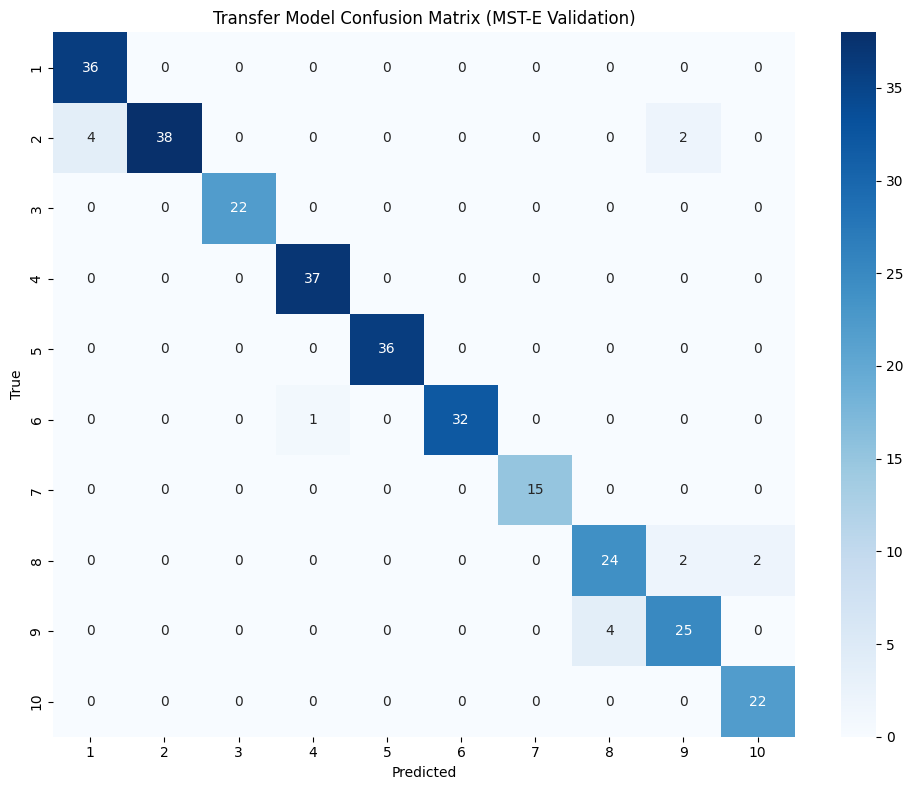

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the transferred model on MST-E validation set
transfer_model.eval()
val_running_loss = 0.0
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in m_val_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = transfer_model(images)
        loss = criterion(outputs, labels)
        val_running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_labels.append(labels.cpu())
        all_preds.append(preds.cpu())

all_labels = torch.cat(all_labels).numpy()
all_preds = torch.cat(all_preds).numpy()

val_loss = val_running_loss / len(m_val_ds)
val_acc = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
val_precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
val_recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
val_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

print(f"Transfer Model Validation Loss: {val_loss:.4f}")
print(f"Transfer Model Validation Accuracy: {val_acc:.2f}%")
print(f"Transfer Model Precision (weighted): {val_precision:.4f}")
print(f"Transfer Model Recall (weighted): {val_recall:.4f}")
print(f"Transfer Model F1 Score (weighted): {val_f1:.4f}")

# Show confusion matrix with MST class labels if available
idx_to_class = {v: k for k, v in class_to_idx.items()} if "class_to_idx" in globals() else {}
ordered_labels = [idx_to_class.get(i, f"Class {i}") for i in range(cm.shape[0])]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.title("Transfer Model Confusion Matrix (MST-E Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

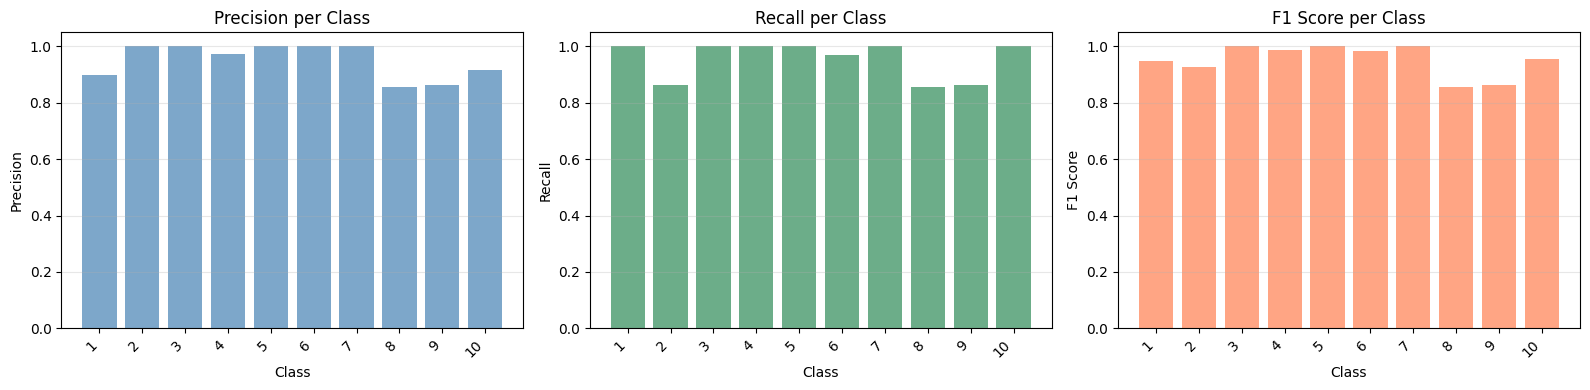

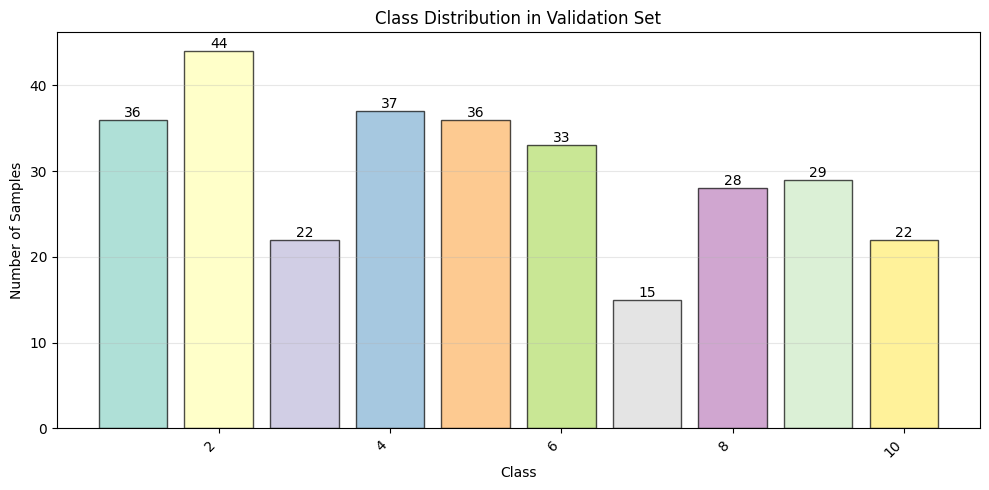

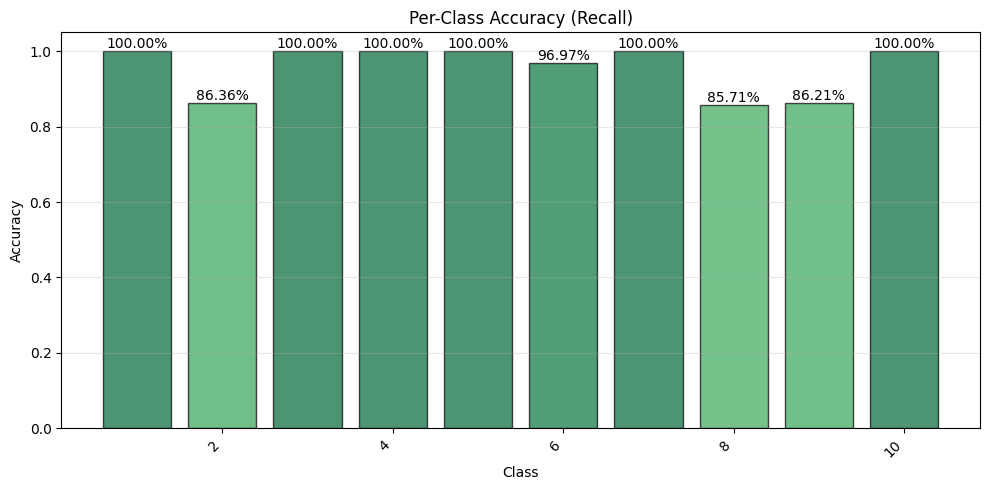


Per-class Precision: {1: 0.9, 2: 1.0, 3: 1.0, 4: 0.9737, 5: 1.0, 6: 1.0, 7: 1.0, 8: 0.8571, 9: 0.8621, 10: 0.9167}
Per-class Recall: {1: 1.0, 2: 0.8636, 3: 1.0, 4: 1.0, 5: 1.0, 6: 0.9697, 7: 1.0, 8: 0.8571, 9: 0.8621, 10: 1.0}
Per-class F1: {1: 0.9474, 2: 0.9268, 3: 1.0, 4: 0.9867, 5: 1.0, 6: 0.9846, 7: 1.0, 8: 0.8571, 9: 0.8621, 10: 0.9565}
Per-class Accuracy: {1: 1.0, 2: 0.8636, 3: 1.0, 4: 1.0, 5: 1.0, 6: 0.9697, 7: 1.0, 8: 0.8571, 9: 0.8621, 10: 1.0}


In [32]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

# Per-class metrics
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    all_labels, all_preds, average=None, zero_division=0
)

# Get class names
idx_to_class = {v: k for k, v in class_to_idx.items()} if "class_to_idx" in globals() else {}
class_names = [idx_to_class.get(i, f"Class {i}") for i in range(len(precision_per_class))]

# 1. Per-class metrics bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x_pos = np.arange(len(class_names))
axes[0].bar(x_pos, precision_per_class, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision per Class')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_ylim([0, 1.05])
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x_pos, recall_per_class, color='seagreen', alpha=0.7)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall per Class')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_ylim([0, 1.05])
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(x_pos, f1_per_class, color='coral', alpha=0.7)
axes[2].set_xlabel('Class')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score per Class')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(class_names, rotation=45, ha='right')
axes[2].set_ylim([0, 1.05])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Class distribution in validation set
unique_labels, counts = np.unique(all_labels, return_counts=True)
plt.figure(figsize=(10, 5))
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
bars = plt.bar([class_names[i] for i in unique_labels], counts, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Validation Set')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Per-class accuracy (diagonal of confusion matrix normalized)
per_class_accuracy = np.diag(cm) / cm.sum(axis=1)
plt.figure(figsize=(10, 5))
colors = plt.cm.RdYlGn(per_class_accuracy)
bars = plt.bar([class_names[i] for i in range(len(per_class_accuracy))], per_class_accuracy, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy (Recall)')
plt.ylim([0, 1.05])
plt.xticks(rotation=45, ha='right')
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPer-class Precision: {dict(zip(class_names, precision_per_class.round(4)))}")
print(f"Per-class Recall: {dict(zip(class_names, recall_per_class.round(4)))}")
print(f"Per-class F1: {dict(zip(class_names, f1_per_class.round(4)))}")
print(f"Per-class Accuracy: {dict(zip(class_names, per_class_accuracy.round(4)))}")